# Experiment 1 – Naïve Bayes Classification

Use the Breast Cancer Wisconsin dataset to build a **Naïve Bayes classifier**.  
Split the dataset into training and testing sets, train the model, predict class labels, and evaluate performance using **accuracy, confusion matrix, classification report, and precision-recall curve**.

First 5 Rows of Dataset:

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wo

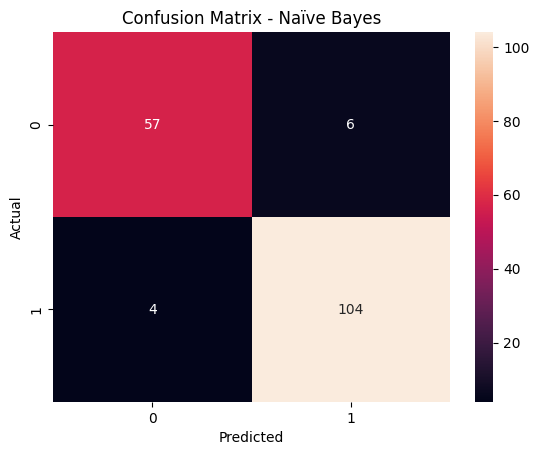


Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.90      0.92        63
           1       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



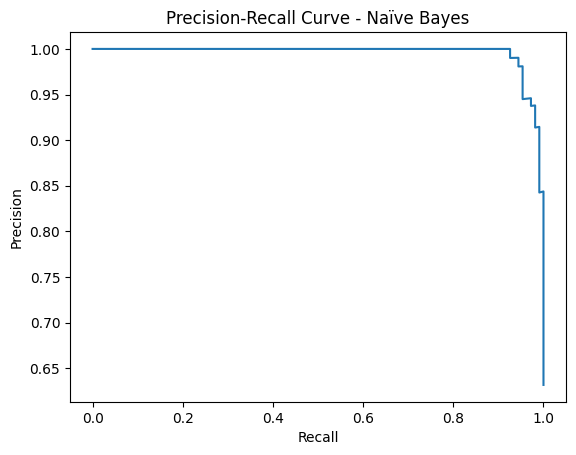

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

#Load Dataset
data = load_breast_cancer()

# Convert to DataFrame for basic viewing
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Basic Dataset Information (Very Minimal)
print("First 5 Rows of Dataset:\n")
print(df.head())

print("\nDataset Shape:", df.shape)
print("Target Classes:", data.target_names)

# 3️⃣ Split into Training and Testing Sets
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Naïve Bayes Classifier
model = GaussianNB()
model.fit(X_train, y_train)

#Predict Test Data
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Confusion Matrix (Printed + Plotted)
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Naïve Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

#Precision-Recall Curve
y_prob = model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Naïve Bayes")
plt.show()